In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load sector data
sectors_raw = pd.read_csv("../data/raw/japan_sectors_raw.csv",
                         encoding='latin-1',
                         index_col=False)

print(f"Shape: {sectors_raw.shape}")
print(f"\nColumns: {sectors_raw.columns.tolist()}")
print(f"Unique HS codes: {sectors_raw['cmdCode'].unique()}")
print(f"Unique years: {sorted(sectors_raw['refYear'].unique())}")
print(f"\nFlow types: {sectors_raw['flowDesc'].unique()}")
sectors_raw.head(3)

Shape: (120, 47)

Columns: ['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period', 'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO', 'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification', 'cmdCode', 'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty', 'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate']
Unique HS codes: [27 29 72 84 85 87]
Unique years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Flow types: <StringArray>
['Import', 'Export']
Length: 2, 

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20140101,2014,52,2014,392,JPN,Japan,M,...,NaN,False,NaN,False,2.621061e+11,NaN,2.621061e+11,0,True,False
1,C,A,20140101,2014,52,2014,392,JPN,Japan,M,...,NaN,False,NaN,False,1.521086e+10,NaN,1.521086e+10,0,True,False
2,C,A,20140101,2014,52,2014,392,JPN,Japan,M,...,NaN,False,NaN,False,8.524468e+09,NaN,8.524468e+09,0,True,False


In [10]:
# Why these 5 columns:
# cmdCode = the HS sector code (27=Energy, 87=Auto, etc..)
# cmdDesc = human readable sector name for verification
# We keep both to map codes -> sector labels cleanly

cols = ['refYear', 'flowDesc', 'cmdCode', 'cmdDesc', 'primaryValue']
sectors = sectors_raw[cols].copy()

sectors = sectors.rename(columns={
    'refYear': 'year',
    'flowDesc': 'flow',
    'cmdCode': 'hs_code',
    'cmdDesc': 'hs_desc',
    'primaryValue': 'value_usd'
})

print("Cleaned shape:", sectors.shape)
print("\nHS codes and descriptions:")
print(sectors.groupby(['hs_code', 'hs_desc']).size().reset_index().
                      drop(columns=0).to_string(index=False))

Cleaned shape: (120, 5)

HS codes and descriptions:
 hs_code                                                                                                                                                                             hs_desc
      27                                                                                Mineral fuels, mineral oils and products of their distillation; bituminous substances; mineral waxes
      29                                                                                                                                                                   Organic chemicals
      72                                                                                                                                                                      Iron and steel
      84                                                                                                       Machinery and mechanical appliances, boilers, nuclear reactors; parts thereof
   

### Map HS codes to sector names

In [13]:
# Why create sector_name column:
# HS codes like 84, 85, 87 are meaningless to readers
# "Machinery", "Electronics", "Automotive" are instantly clear

sector_map = {
    27: 'Energy(Fuels)',
    29: 'Chemicals',
    72: 'Steel & Metals',
    84: 'Machinery',
    85: 'Electronics',
    87: 'Automotive'
}
sectors['sector'] = sectors['hs_code'].map(sector_map)
sectors['value_bn'] = sectors['value_usd'] / 1e9

print("Sectors Mapped:")
print(sectors['sector'].unique())
print(f"\nNull sectors: {sectors['sector'].isnull().sum()}")
print(f"\nShape: {sectors.shape}")
sectors.head(6)

Sectors Mapped:
<StringArray>
[ 'Energy(Fuels)',      'Chemicals', 'Steel & Metals',      'Machinery',
    'Electronics',     'Automotive']
Length: 6, dtype: str

Null sectors: 0

Shape: (120, 7)


,year,flow,hs_code,hs_desc,value_usd,sector,value_bn
0,2014,Import,27,"Mineral fuels, mineral oils and products of th...",2.621061e+11,Energy(Fuels),262.106100
1,2014,Import,29,Organic chemicals,1.521086e+10,Chemicals,15.210857
2,2014,Import,72,Iron and steel,8.524468e+09,Steel & Metals,8.524468
3,2014,Import,84,"Nuclear reactors, boilers, machinery and mecha...",6.504161e+10,Machinery,65.041607
4,2014,Import,85,Electrical machinery and equipment and parts t...,9.934624e+10,Electronics,99.346235
5,2014,Import,87,Vehicles; other than railway or tramway rollin...,2.156627e+10,Automotive,21.566267


### Export sector breakdown 2023

In [15]:
# Why focus on exports first:
# Japan's Export sector composition tells us WHERE
# Japan's competitive strength lies
# Import sectors tells us WHERE Japan is dependent
# Exports = strength. Imports = vulnerability.

exports_2023 = sectors[
    (sectors['year'] == 2023) & (sectors['flow'] == 'Export')
].copy()

exports_2023 = exports_2023.sort_values('value_bn', ascending=False)

print("Japan Export Sectors (2023)")
print(exports_2023[['sector', 'value_bn']].to_string(index=False))

total_exports = exports_2023['value_bn'].sum()
exports_2023['share_pct'] = (exports_2023['value_bn']/
                             total_exports * 100).round(1)

print(f"\nTotal (these 6 sectors): ${total_exports:.1f}bn")
print("\nWith shares:")
print(exports_2023[['sector', 'value_bn', 'share_pct']].to_string(index=False))

Japan Export Sectors (2023)
        sector   value_bn
    Automotive 157.301991
     Machinery 129.710721
   Electronics 101.888300
Steel & Metals  30.465519
     Chemicals  14.774153
 Energy(Fuels)  12.726473

Total (these 6 sectors): $446.9bn

With shares:
        sector   value_bn  share_pct
    Automotive 157.301991       35.2
     Machinery 129.710721       29.0
   Electronics 101.888300       22.8
Steel & Metals  30.465519        6.8
     Chemicals  14.774153        3.3
 Energy(Fuels)  12.726473        2.8


### Export Sector Bar Chart

In [ ]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 15,
    'axes.titleweight': '500',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

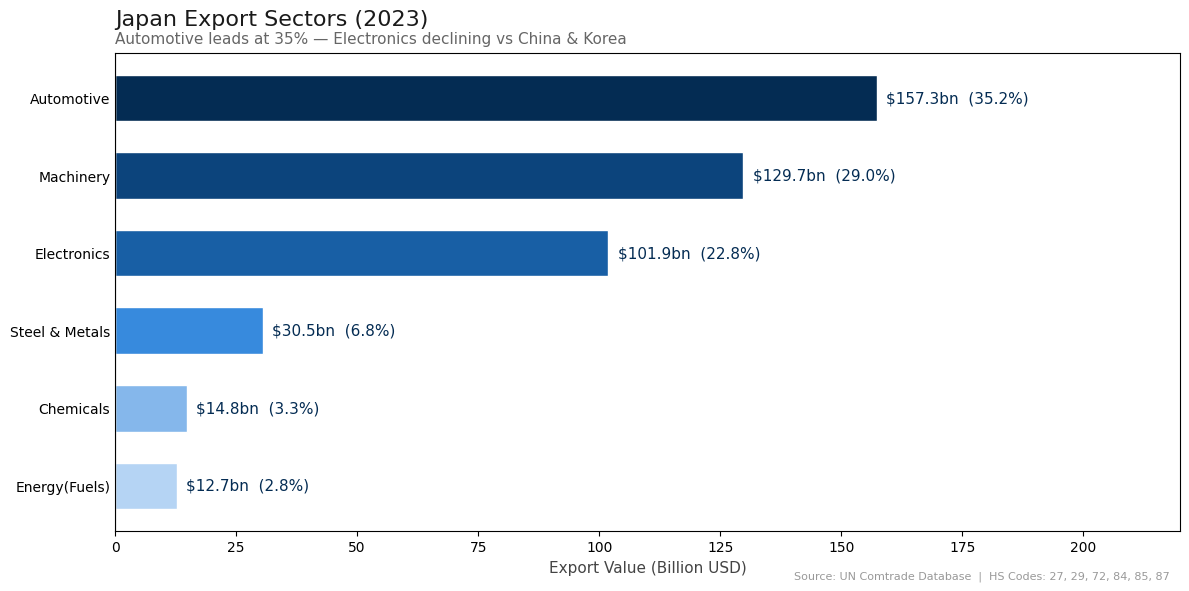

✓ Saved


In [22]:
colors = {
    'Automotive':     '#D32F2F',
    'Electronics':    '#1565C0',
    'Machinery':      '#2E7D32',
    'Chemicals':      '#F57F17',
    'Steel & Metals': '#6A1B9A',
    'Energy (Fuels)': '#37474F'
}

bar_colors = [colors.get(s, '#888') for s in exports_2023['sector']]


# WHY horizontal bar chart:
# Sector names are long — horizontal gives space to read them
# Sorted bars = instantly shows ranking without reading numbers
# Much more readable than vertical bars with rotated labels

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

# Sort ascending so largest is at TOP
exports_sorted = exports_2023.sort_values('value_bn')

# WHY single color family with intensity variation:
# Different colors per bar = visual noise, no meaning
# Same color family, darker = larger = encodes magnitude
palette = ['#B5D4F4','#85B7EB','#378ADD','#185FA5','#0C447C','#042C53']

bars = ax.barh(exports_sorted['sector'],
               exports_sorted['value_bn'],
               color=palette,
               edgecolor='white',
               height=0.6)

# WHY annotate outside the bar:
# Inside labels get hidden when bar is short
# Outside labels are always readable
for bar, val, pct in zip(bars,
                          exports_sorted['value_bn'],
                          exports_sorted['share_pct']):
    ax.text(bar.get_width() + 2,
            bar.get_y() + bar.get_height()/2,
            f'${val:.1f}bn  ({pct}%)',
            va='center', fontsize=11,
            color='#042C53', fontweight='500')

# Title + subtitle — two-level typography
ax.set_title('Japan Export Sectors (2023)',
             fontsize=16, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')

ax.text(0, 1.02,
        'Automotive leads at 35% — Electronics declining vs China & Korea',
        transform=ax.transAxes,
        fontsize=11, color='#666666')

ax.set_xlabel('Export Value (Billion USD)', fontsize=11, color='#444')
ax.set_xlim(0, 220)
ax.axvline(x=0, color='#CCCCCC', linewidth=1)
ax.tick_params(axis='y', length=0)

ax.text(0.99, -0.1,
        'Source: UN Comtrade Database  |  HS Codes: 27, 29, 72, 84, 85, 87',
        transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right')

plt.tight_layout()
plt.savefig("../reports/export_sectors_2023_pro.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")


### Import sector breakdown 2023

In [20]:
# Why Imports matter here:
# Energy (HS 27) imports reveal Japan's Energy vulnerability
# Comparing Export vs Import in same sectors show
# Whether Japan is net buyer or seller in each category

imports_2023 = sectors[
    (sectors['year'] == 2023) & (sectors['flow'] == 'Import')
]

imports_2023 = imports_2023.sort_values('value_bn', ascending=False)
total_imports = imports_2023['value_bn'].sum()

imports_2023['share_pct'] = (imports_2023['value_bn']/
                             total_exports * 100).round(1)

print("Japan Import Sectors (2023)")
print(imports_2023[['sector', 'value_bn', 'share_pct']].to_string(index=False))

Japan Import Sectors (2023)
        sector   value_bn  share_pct
 Energy(Fuels) 194.666525       43.6
   Electronics 115.086540       25.8
     Machinery  69.312563       15.5
    Automotive  24.895148        5.6
     Chemicals  15.347806        3.4
Steel & Metals   8.321485        1.9


### Export vs Import comparison by sector

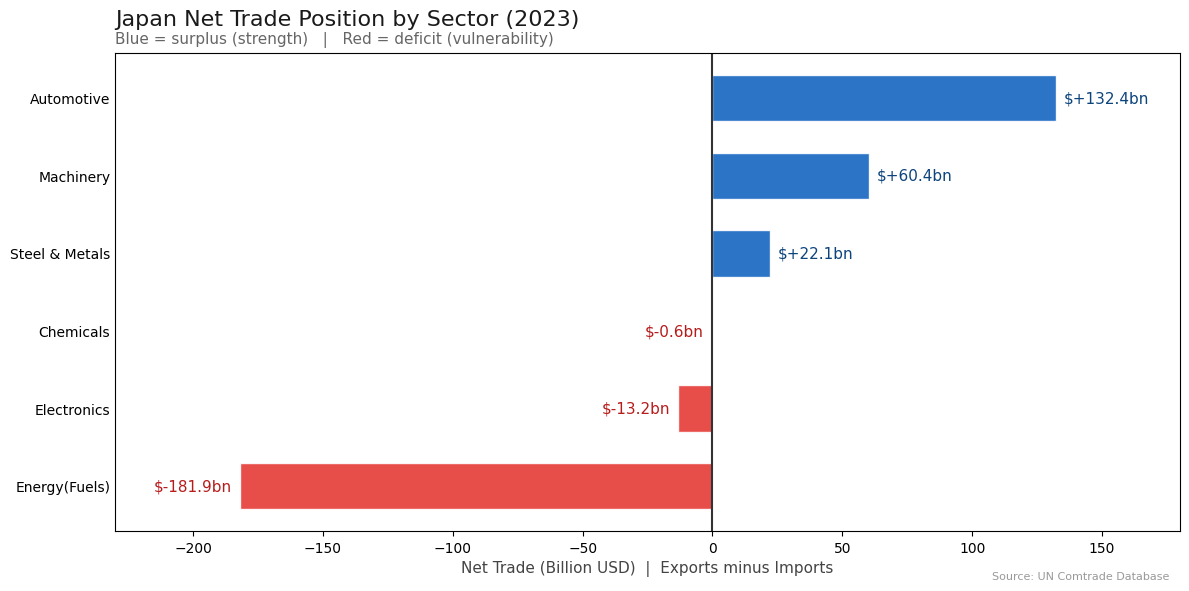

✓ Saved


In [23]:
# WHY diverging bar chart:
# Positive = surplus (Japan exports more)
# Negative = deficit (Japan imports more)
# Diverging from zero = instantly shows direction
# This is how economists show net trade position

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

net_sorted = comparison.sort_values('net_bn')

# WHY different colors for positive/negative:
# Blue = surplus = strength
# Red = deficit = vulnerability
# The color itself carries the message — no legend needed
bar_colors = ['#E53935' if v < 0 else '#1565C0'
              for v in net_sorted['net_bn']]

bars = ax.barh(net_sorted['sector'],
               net_sorted['net_bn'],
               color=bar_colors,
               edgecolor='white',
               height=0.6,
               alpha=0.9)

for bar, val in zip(bars, net_sorted['net_bn']):
    x_pos = bar.get_width()
    ha = 'left' if val >= 0 else 'right'
    offset = 3 if val >= 0 else -3
    color = '#0C447C' if val >= 0 else '#B71C1C'
    ax.text(x_pos + offset,
            bar.get_y() + bar.get_height()/2,
            f'${val:+.1f}bn',
            va='center', fontsize=11,
            color=color, fontweight='500', ha=ha)

ax.axvline(x=0, color='#333333', linewidth=1.5)

ax.set_title('Japan Net Trade Position by Sector (2023)',
             fontsize=16, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')

ax.text(0, 1.02,
        'Blue = surplus (strength)   |   Red = deficit (vulnerability)',
        transform=ax.transAxes,
        fontsize=11, color='#666666')

ax.set_xlabel('Net Trade (Billion USD)  |  Exports minus Imports',
              fontsize=11, color='#444')
ax.tick_params(axis='y', length=0)
ax.set_xlim(-230, 180)

ax.text(0.99, -0.1,
        'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right')

plt.tight_layout()
plt.savefig("../reports/sector_net_position_pro.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

## Key Finding 8 — Japan's Sector Trade Position (2023)

Japan's trade strength is built entirely on three manufacturing sectors:
Automotive (+$132bn), Machinery (+$60bn), and Steel & Metals (+$22bn).

Two major vulnerabilities emerge:

**Energy (-$182bn):** Japan imports $195bn in mineral fuels while 
exporting only $13bn. This single sector creates Japan's entire 
structural trade deficit. Without energy imports, Japan would run 
a $200bn+ annual surplus. Every yen that weakens costs Japan more 
on this $195bn energy bill.

**Electronics (-$13bn):** Japan was once the world leader in 
consumer electronics. Today Japan is a net importer — buying $115bn 
from China and Korea while selling $102bn. This represents a 
structural decline in a historic Japanese strength, driven by 
competition from Samsung, LG, and Chinese manufacturers.

METI implication: Japan's economic security requires both an energy 
transition (reduce the -$182bn drag) and a semiconductor/electronics 
revival strategy (reverse the electronics deficit).